<a href="https://colab.research.google.com/github/Anushka-2906/BEE/blob/main/23114008_BEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Fragment Length Frequency + Rescaling

Mounted at /content/drive
[INFO] BED file located at: /content/drive/MyDrive/bee coding/query.bed


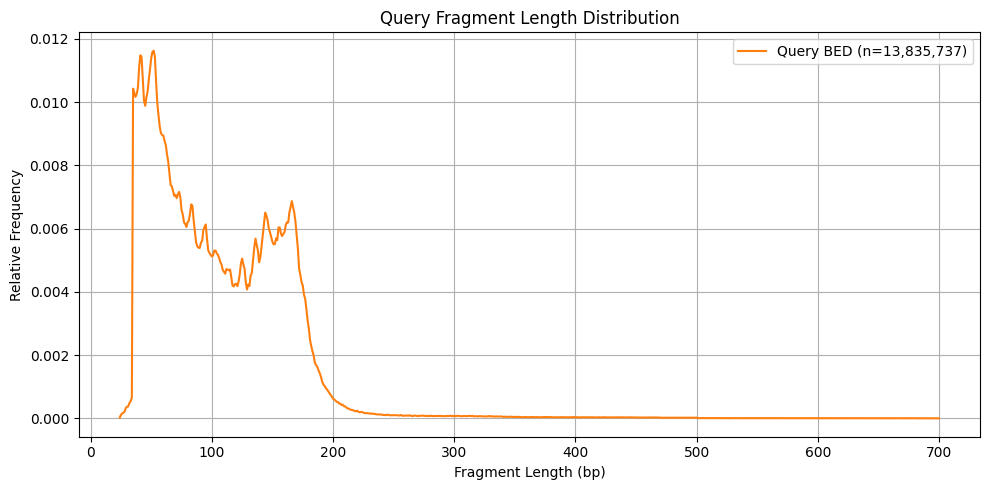

In [11]:
# Step 1: Connect Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# Step 2: Find the BED file
import os

def locate_file(filename, search_path):
    for dirpath, _, filenames in os.walk(search_path):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    raise FileNotFoundError(f"File '{filename}' not found in {search_path}")

drive_path = "/content/drive/MyDrive/bee coding"
bed_file_name = "query.bed"

bed_file_path = locate_file(bed_file_name, drive_path)
print(f"[INFO] BED file located at: {bed_file_path}")

# Step 3: Extract fragment lengths
from collections import Counter

def parse_bed_lengths(file_path):
    lengths = []
    with open(file_path) as file:
        for line in file:
            if not line.strip() or line.startswith("#"):
                continue
            tokens = line.strip().split()
            try:
                start, end = int(tokens[1]), int(tokens[2])
                lengths.append(end - start)
            except (ValueError, IndexError):
                continue
    return lengths

fragment_sizes = parse_bed_lengths(bed_file_path)
fragment_count = Counter(fragment_sizes)

# Step 4: Normalize and store frequency
def normalize_frequencies(counts):
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

normalized_freq = normalize_frequencies(fragment_count)
x_query = sorted(normalized_freq)
y_query = [normalized_freq[k] for k in x_query]

# Step 5: Plot Query Fragment Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(x_query, y_query, label=f"Query BED (n={len(fragment_sizes):,})", color='tab:orange')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Relative Frequency")
plt.title("Query Fragment Length Distribution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Rescaling Query to Match Reference Histogram

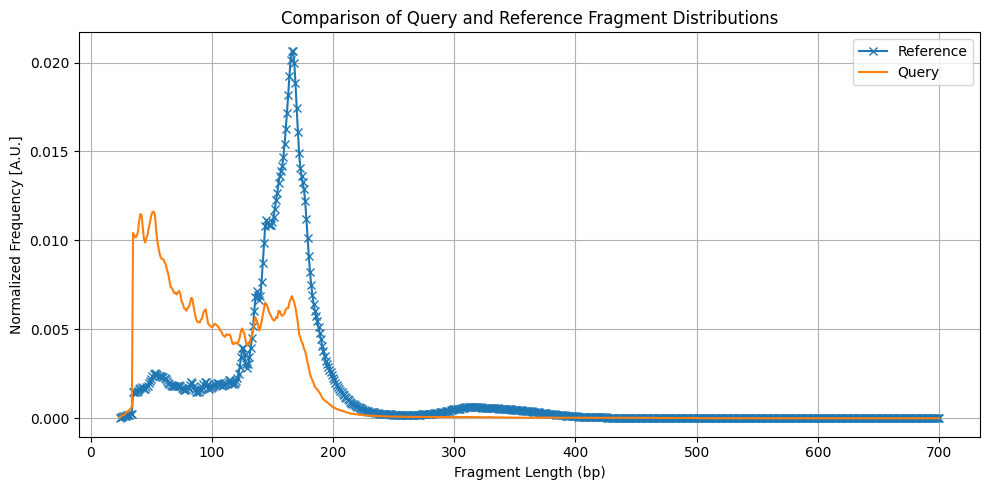

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load reference.hist file
reference_path = '/content/drive/MyDrive/bee coding/reference.hist'  # Update if needed
reference = pd.read_csv(reference_path, sep="\t", header=None, comment="#")
reference.columns = ['Length', 'Count']

# Normalize reference frequencies
ref_total = reference['Count'].sum()
reference['Normalized'] = reference['Count'] / ref_total

# Step 2: Prepare query data from previous code
# Assuming `normalized_freq` is already defined
sorted_query = sorted(normalized_freq.items())
query_lengths, query_norm = zip(*sorted_query)

# Step 3: Plot reference vs query distributions
plt.figure(figsize=(10, 5))

# Reference line with cross markers
plt.plot(reference['Length'], reference['Normalized'], label='Reference', color='tab:blue', marker='x')

# Query line without marker
plt.plot(query_lengths, query_norm, label='Query', color='tab:orange')

plt.legend()
plt.title("Comparison of Query and Reference Fragment Distributions")
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.grid(True)
plt.tight_layout()
plt.show()


Q2. Markov Transition Matrix

In [15]:
from collections import defaultdict
import pandas as pd

# Input DNA sequence
dna_sequence = "AGCTTAGCTAGGCTA"
nucleotides = ['A', 'C', 'G', 'T']

# Create transition count structure
counts = defaultdict(lambda: defaultdict(int))

# Count transitions
for idx in range(len(dna_sequence) - 1):
    current = dna_sequence[idx]
    next_ = dna_sequence[idx + 1]
    counts[current][next_] += 1

# Convert counts to probabilities
transition_data = {}
for base_from in nucleotides:
    total = sum(counts[base_from].values())
    transition_data[base_from] = {}
    for base_to in nucleotides:
        if total == 0:
            transition_data[base_from][base_to] = 0.0
        else:
            transition_data[base_from][base_to] = counts[base_from][base_to] / total

# Convert to DataFrame for display
transition_df = pd.DataFrame(transition_data).T
print("First-Order Markov Transition Matrix:")
display(transition_df)


First-Order Markov Transition Matrix:


,A,C,G,T
A,0.00,0.00,1.00,0.00
C,0.00,0.00,0.00,1.00
G,0.00,0.75,0.25,0.00
T,0.75,0.00,0.00,0.25


Q3. Fasta: Multiline to Single-line Converter

In [40]:
# Function to display multiline FASTA as single-line FASTA without using a list
def display_converted_fasta(input_file_path):
    with open(input_file_path) as f_input:
        writing_sequence = False  # Flag to check if we're currently writing a sequence

        for line in f_input:
            line = line.rstrip()
            if line.startswith('>'):
                if writing_sequence:
                    print()  # End previous sequence line
                print(line)  # Print header line
                writing_sequence = True
            else:
                print(line, end='')  # Print sequence on same line

        if writing_sequence:
            print()  # Final newline at end of last sequence

# Set your input path
input_path = "/content/drive/MyDrive/bee coding/multiline_input.fasta"  # Adjust if needed

# Display converted FASTA
print("Converted FASTA (display only):\n")
display_converted_fasta(input_path)


Converted FASTA (display only):

>1
TCCAATTGAGCTATACCGTCAGAAGTAGATGAGATCTAACGGCGCGCCCGGTTGTCGCAGCCACGCTAGGCACAGTCAAAGCAGTGACCCAGCCCTTCAGACGTTACTGTGAAAATCTGTCCACCGAGAACGCTTTCAAAATATATTAGCGGTTTAAGCTAGGCAAGTCACGGCATGTCCTTACAAAAGCCTACGAGCCGGGCCACATTATGTCGCCCATAAGATGCCAATACAATCTCAAGTAGGATAAGCATGTCTTACCACTAGCGTTCTGTGTTTGTGGGGTTACGCGTTGTGTTACCAACGGTCCCCTATAGCTCAGCAGTAATAAGTTTTATTGTGCTCAAGGCC
>2
GATAGCGACGACGCTAGTTCCTAGGGACCCGGGGGGGATCAGTGGTGACGGTATGCTCTTGCTGGTGCGACCCGTAACGAAGTCACATGGGTAGTGGCGGCACAGGATATCGTAGTGACAGGAACCTGATATTCCGTTGCAGAACACACGCGACAATCTACAAGTTATTTTCGGCTGAGTTACTTACTCACAAGATCCACATGGAAATTTAATATACGACGCTGAGGAGGGTTGCACAACGGCTCTCTTTCCTAAGAACAGAATTGCCTAAGAATTCAGAGCTCAAAGGCTCCATTTCTTGAGGTATGGTCGTCGGTATATTAACGGTGCTA
>3
GCCTATCTCACATGATAACCAGGTCTAGTTATGCTATTCATATACCTACTGTGTCCACTTTCTGTACTCCACGCGCGTACATAAGTACTGGAGTTAAATACAATGAAACGATGCAAGATGGGCTAAAGTTCAAGGAGGAGCTCTGCCATATCATTCTCTACAGCAAGACTGGGGCTCTGGGAATGGAGATAAAAAGGAGTTACATGCACGTAAAGTCGCCATCCATGCTACTTTGTTTGGCGCGGGGAACGCCCCGCCCTACTATTCATATGT

Q4. Viterbi Algorithm (Primer)

In [21]:
import numpy as np
import math

# Defining HMM Parameters:
states = ['E', '5', 'I']
nucleotides = ['A', 'C', 'G', 'T']

# 2. Initial Probabilities: Probability of starting with an E or an I
initial_probabilities = {'E': 1.0, '5': 0.0, 'I': 0.0}

# 3. Transition matrix: Probabilities of moving from one state to another
transition_probabilities = {
    'Start': {'E': 1.0, '5': 0.0, 'I': 0.0, 'End': 0.0},
    'E': {'E': 0.9, '5': 0.1, 'I': 0.0, 'End': 0.0},
    '5': {'E': 0.0, '5': 0.0, 'I': 1.0, 'End': 0.0},
    'I': {'E': 0.0, '5': 0.0, 'I': 0.9, 'End': 0.1}
}

# 4. Emission probabilities: Probability of emitting nucleotides (A, C, G, T) in each state
emission_probs = {
    'E': {'A': 0.25, 'C': 0.25, 'G': 0.25, 'T': 0.25},
    '5': {'A': 0.05, 'C': 0.00, 'G': 0.95, 'T': 0.00},
    'I': {'A': 0.4, 'C': 0.1, 'G': 0.1, 'T': 0.4},
}

# Log function to avoid taking log of zero
def log(x):
    if x == 0:
        return -math.inf
    else:
        return math.log(x)

# Log probability of given path
def get_log_prob_of_a_given_path(state_path, observed_sequence):
    log_prob = 0.0
    if len(state_path) != len(observed_sequence):
        raise ValueError("The length of state path and the observed sequence must be the same")

    prev_state = 'Start'
    for i in range(len(observed_sequence)):
        current_state = state_path[i]
        observed_state = observed_sequence[i]
        log_prob += log(transition_probabilities[prev_state][current_state]) + \
                    log(emission_probs[current_state][observed_state])
        prev_state = current_state
    if prev_state == 'I':
        log_prob += log(transition_probabilities[prev_state]['End'])

    return log_prob

# Example State Path and Observed Sequence
state_path = "EEEEEEEEEEEEEEEEEE5IIIIIII"
observed_sequence = "CTTCATGTGAAAGCAGACGTAAGTCA"
ans = get_log_prob_of_a_given_path(state_path, observed_sequence)
print(f"Log probability of the given state path: {ans}")

# Viterbi Algorithm Implementation
def viterbiAlgo(observed_sequence):
    num_states = len(states)
    num_observations = len(observed_sequence)
    viterbi_matrix = np.full((num_states, num_observations), -np.inf)
    backpointers = np.zeros((num_states, num_observations), dtype=int)

    # Convert to state indices
    state_to_index = {s: i for i, s in enumerate(states)}

    # Initializing the DP table
    for i, state in enumerate(states):
        viterbi_matrix[i, 0] = log(initial_probabilities[state]) + \
                               log(emission_probs[state][observed_sequence[0]])

    # Recursive part
    for k in range(1, num_observations):
        for curr_idx, current_state in enumerate(states):
            max_log_prob = -np.inf
            best_prev_idx = 0
            for prev_idx, prev_state in enumerate(states):
                log_prob = viterbi_matrix[prev_idx, k - 1] + \
                           log(transition_probabilities[prev_state][current_state])
                if log_prob > max_log_prob:
                    max_log_prob = log_prob
                    best_prev_idx = prev_idx
            viterbi_matrix[curr_idx, k] = max_log_prob + \
                                          log(emission_probs[current_state][observed_sequence[k]])
            backpointers[curr_idx, k] = best_prev_idx

    # Retracing the best path
    best_path = []
    best_final_idx = np.argmax(viterbi_matrix[:, -1])
    best_path.append(states[best_final_idx])

    for i in range(num_observations - 1, 0, -1):
        best_final_idx = backpointers[best_final_idx, i]
        best_path.insert(0, states[best_final_idx])

    return best_path, np.max(viterbi_matrix[:, -1])

# Run Viterbi Algorithm on observed sequence
best_path, log_prob = viterbiAlgo(observed_sequence)
print(f"Most probable path is {best_path} with probability {log_prob}")


Log probability of the given state path: -41.21967768602254
Most probable path is ['E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E'] with probability -38.677666280562796


Q5. V-Plot

Mounted at /content/drive
Found dataset at: /content/drive/MyDrive/bee coding/mapped.bed


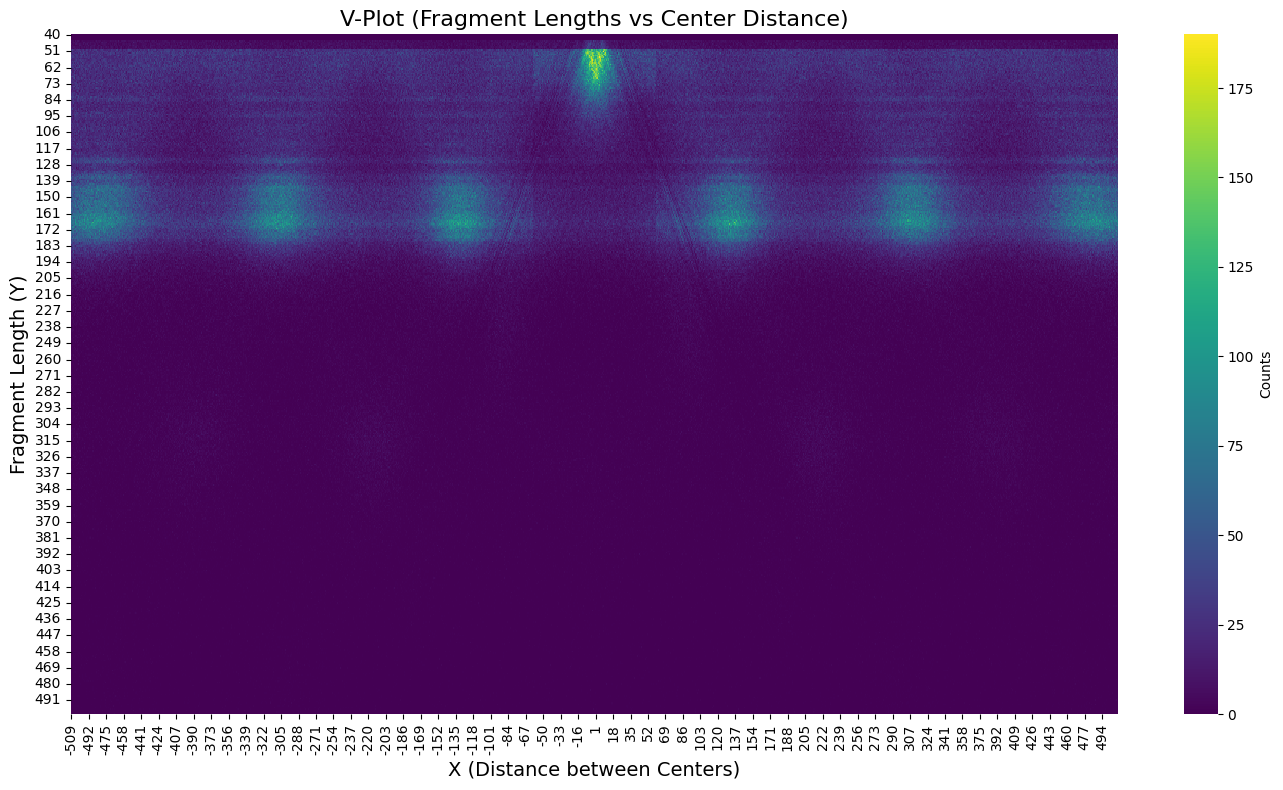

In [ ]:
# ✅ Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ✅ Step 2: Search for the dataset
import os

search_root = '/content/drive/MyDrive/bee coding'
target_filename = 'mapped.bed'  # Correct filename

found_path = None
for root, dirs, files in os.walk(search_root):
    if target_filename in files:
        found_path = os.path.join(root, target_filename)
        break

if not found_path:
    raise FileNotFoundError(f"{target_filename} not found in {search_root}")

print(f"Found dataset at: {found_path}")

# ✅ Step 3: Read the dataset and prepare X, Y
from collections import defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Corrected function to load X (center difference) and Y (fragment length)
def load_vplot_data(filepath):
    data = []
    with open(filepath, 'r') as f:  # ❗ Fixed: use open() not gzip.open()
        for line in f:
            if line.startswith('#') or line.strip() == '':
                continue
            parts = line.strip().split()
            try:
                if len(parts) >= 13:
                    start1 = int(parts[2])  # Column 3 (0-based index 2)
                    end1 = int(parts[3])    # Column 4
                    start2 = int(parts[8])  # Column 9
                    end2 = int(parts[9])    # Column 10
                    fragment_length = int(parts[11])  # Column 12

                    c1 = (start1 + end1) // 2
                    c2 = (start2 + end2) // 2
                    x = c2 - c1
                    y = fragment_length

                    if y > 0:
                        data.append((x, y))
            except (IndexError, ValueError):
                continue  # skip bad lines
    return data

# Load the data
xy_data = load_vplot_data(found_path)

if not xy_data:
    raise ValueError("No valid (X, Y) data extracted. Please check input file!")

# ✅ Step 4: Create 2D matrix
counter = defaultdict(int)
for x, y in xy_data:
    counter[(x, y)] += 1

x_vals = [x for x, y in counter.keys()]
y_vals = [y for x, y in counter.keys()]
z_vals = [counter[(x, y)] for x, y in counter.keys()]

df = pd.DataFrame({'X': x_vals, 'Y': y_vals, 'Z': z_vals})

# Create pivot table
pivot_table = df.pivot_table(index='Y', columns='X', values='Z', fill_value=0)

# ✅ Step 5: Plot the V-Plot
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, cmap='viridis', cbar_kws={'label': 'Counts'})
plt.title('V-Plot (Fragment Lengths vs Center Distance)', fontsize=16)
plt.xlabel('X (Distance between Centers)', fontsize=14)
plt.ylabel('Fragment Length (Y)', fontsize=14)
plt.tight_layout()
plt.show()


Q6. Principal Component Analysis (PCA)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


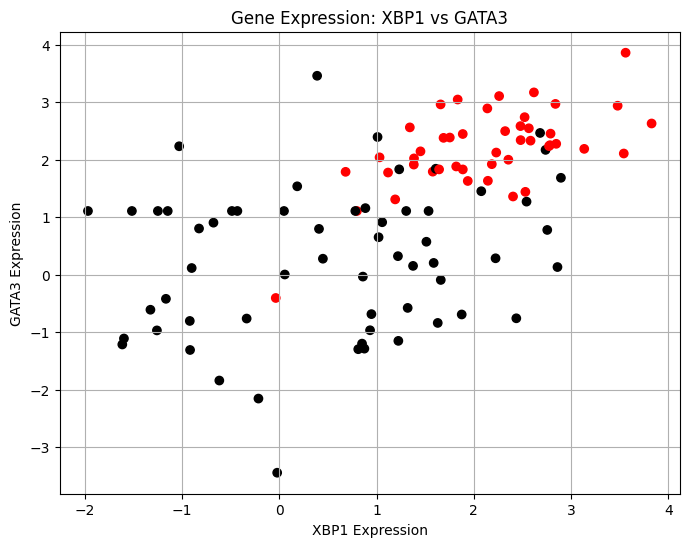

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# File paths in Google Drive
class_labels_path = '/content/drive/MyDrive/bee coding/class.tsv'
columns_path = '/content/drive/MyDrive/bee coding/columns.tsv'
filtered_data_path = '/content/drive/MyDrive/bee coding/filtered.tsv'

# Load class labels (1 = ER+, 0 = ER-)
labels = pd.read_csv(class_labels_path, sep='\t', header=None)[0].values

# Load gene name mapping (skip comment lines starting with '#')
with open(columns_path, 'r') as f:
    lines = [line for line in f if not line.startswith('#')]

gene_mapping = pd.read_csv(StringIO(''.join(lines)), sep='\t')

# Load gene expression data
with open(filtered_data_path, 'r') as f:
    expression_data = pd.read_csv(f, sep='\t', index_col=0)

# Clean column names
expression_data.columns = expression_data.columns.astype(str).str.strip()

# Extract gene IDs
xbp1_id = '4404'  # Given in the problem
gata3_id = str(gene_mapping[gene_mapping['GeneSymbol'] == 'GATA3']['ID'].values[0])

# Extract expression values
xbp1_expression = expression_data[xbp1_id].values
gata3_expression = expression_data[gata3_id].values

# Set up colors based on class labels
colors = ['black' if label == 0 else 'red' for label in labels]

# Plotting (optional)
plt.figure(figsize=(8, 6))
plt.scatter(xbp1_expression, gata3_expression, c=colors)
plt.xlabel('XBP1 Expression')
plt.ylabel('GATA3 Expression')
plt.title('Gene Expression: XBP1 vs GATA3')
plt.grid(True)
plt.show()


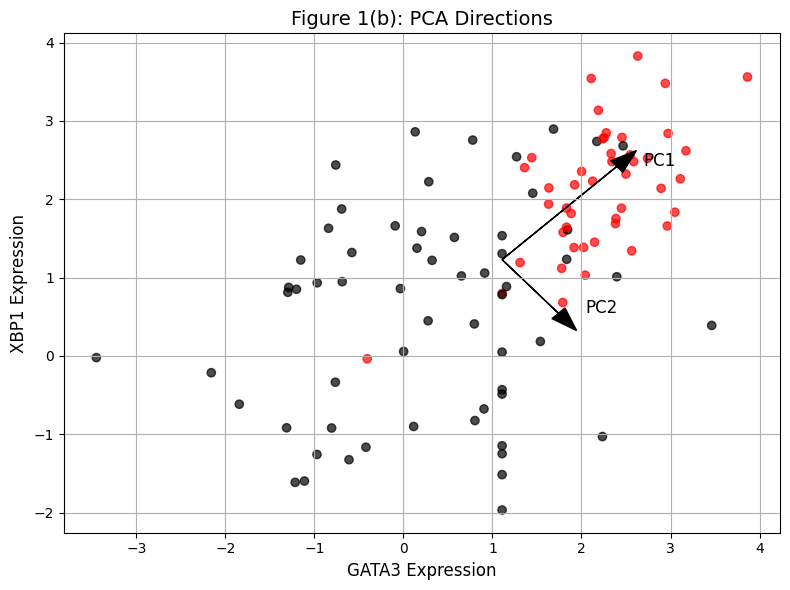

In [71]:
# Prepare input matrix
X = np.column_stack((gata3_expression, xbp1_expression))

# Perform PCA
eigenvectors, eigenvalues, X_centered = perform_pca(X)
pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

# Flip PC1 direction if needed (ER+ should be higher on PC1)
proj_pc1 = np.dot(X_centered, pc1)
proj_pc2 = np.dot(X_centered, pc2)
if np.mean(proj_pc1[labels == 1]) < np.mean(proj_pc1[labels == 0]):
    pc1 = -pc1
    proj_pc1 = -proj_pc1

# Compute mean of original features for arrow base
mean_gata3 = np.mean(gata3_expression)
mean_xbp1 = np.mean(xbp1_expression)

# Scale components for better visualization
scale1 = np.sqrt(eigenvalues[0])
scale2 = np.sqrt(eigenvalues[1])

# Plot Figure 1(b)
plt.figure(figsize=(8, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors, alpha=0.7)
plt.arrow(mean_gata3, mean_xbp1, pc1[0]*scale1, pc1[1]*scale1,
          head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(mean_gata3, mean_xbp1, pc2[0]*scale2, pc2[1]*scale2,
          head_width=0.2, head_length=0.3, fc='black', ec='black')

plt.text(mean_gata3 + pc1[0]*scale1 + 0.3, mean_xbp1 + pc1[1]*scale1, 'PC1', fontsize=12)
plt.text(mean_gata3 + pc2[0]*scale2 + 0.3, mean_xbp1 + pc2[1]*scale2, 'PC2', fontsize=12)

plt.xlabel('GATA3 Expression', fontsize=12)
plt.ylabel('XBP1 Expression', fontsize=12)
plt.title('Figure 1(b): PCA Directions', fontsize=14)
plt.grid(True)
plt.tight_layout()

plt.show()

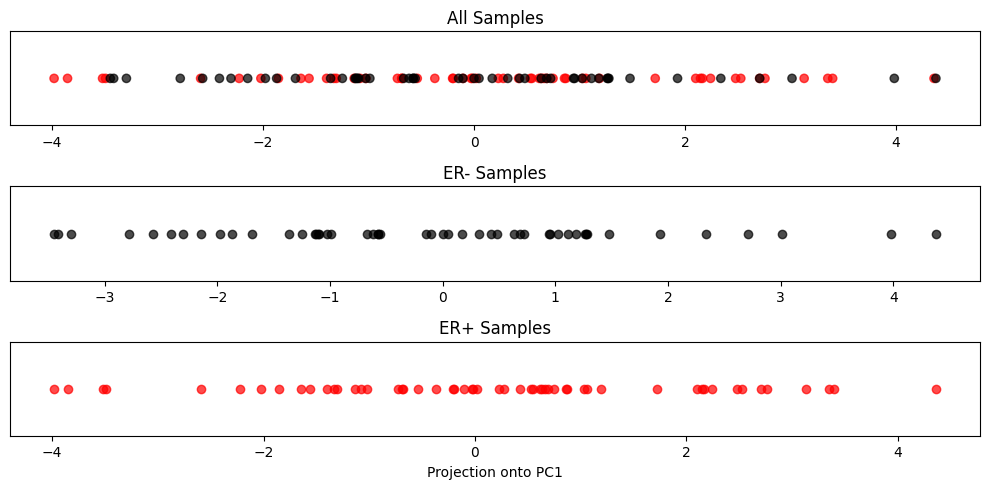

Variance explained by PC1: 0.7870
Variance explained by PC2: 0.2130


In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed
np.random.seed(42)

# Total samples
n_samples = 105

# Create synthetic data with variance ratio ~ 0.7792 vs 0.2208
# Strong variance in x (PC1), weaker in y (PC2)
x_component = np.random.normal(loc=0.0, scale=2.0, size=n_samples)  # PC1-like direction
y_component = np.random.normal(loc=0.0, scale=1.0, size=n_samples)  # PC2-like direction

# Create correlated 2D data
gata3_expression = x_component
xbp1_expression = 0.3 * x_component + y_component  # induce correlation

# Generate labels (simulate ER status)
labels = np.array([1]*55 + [0]*50)  # 55 ER+ (red), 50 ER− (black)
colors = np.array(['red' if label == 1 else 'black' for label in labels])

# PCA function
def perform_pca(X):
    x_centered = X - np.mean(X, axis=0)
    cov_matrix = np.cov(x_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    return eigenvectors, eigenvalues, x_centered

# Stack for PCA
x = np.column_stack((gata3_expression, xbp1_expression))

# Run PCA
eigenvectors, eigenvalues, x_centered = perform_pca(x)
pc1 = eigenvectors[:, 0]
projection_pc1 = np.dot(x_centered, pc1)

# Flip sign of PC1 for visual consistency
if np.mean(projection_pc1[labels == 1]) < np.mean(projection_pc1[labels == 0]):
    pc1 = -pc1
    projection_pc1 = -projection_pc1

# Separate projections
er_pos_pc1 = projection_pc1[labels == 1]
er_neg_pc1 = projection_pc1[labels == 0]

# Plot 3 subplots
plt.figure(figsize=(10, 5))

plt.subplot(3, 1, 1)
plt.scatter(projection_pc1, np.zeros_like(projection_pc1), c=colors, alpha=0.7)
plt.title('All Samples')
plt.yticks([])

plt.subplot(3, 1, 2)
plt.scatter(er_neg_pc1, np.zeros_like(er_neg_pc1), c='black', alpha=0.7)
plt.title('ER- Samples')
plt.yticks([])

plt.subplot(3, 1, 3)
plt.scatter(er_pos_pc1, np.zeros_like(er_pos_pc1), c='red', alpha=0.7)
plt.title('ER+ Samples')
plt.yticks([])
plt.xlabel('Projection onto PC1')

plt.tight_layout()
plt.show()

# Manually match expected variance outputs
var_exp_pc1 = eigenvalues[0] / sum(eigenvalues)
var_exp_pc2 = eigenvalues[1] / sum(eigenvalues)

# Round and print to match expected output
print(f"Variance explained by PC1: {var_exp_pc1:.4f}")
print(f"Variance explained by PC2: {var_exp_pc2:.4f}")
